GEOMETRY PRESERVATION + MDS SHIFT NOTEBOOK

Design:
  Localization: differential COPEs (1, 2, 3, 4) — dynamic per session
  Measurement:  raw betas (COPEs 15-18) — no circularity
  Sphere: 6mm around each session's peak
  Metrics:
    1. Spatial Relocation (centroid distance T1→T2)
    2. Geometry Preservation (RDM correlation T1→T2)
    3. MDS Shift (Procrustes-aligned embedding distance per category)
##############################################################################

In [17]:
# ── CELL 1: Setup ────────────────────────────────────────────────────────────

import os, sys, time
import numpy as np
import nibabel as nib
import pandas as pd
from pathlib import Path
from scipy.ndimage import label, center_of_mass
from scipy.stats import pearsonr, mannwhitneyu, ttest_ind, spearmanr
from scipy.spatial.distance import squareform
from scipy.linalg import orthogonal_procrustes
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, is_patient,
                           get_sessions, get_sub_info, _load_csv)

BASE_DIR = Path(processed_dir)
HOME_OUTPUT = Path('/home/csimmon2/geometry_results')
HOME_OUTPUT.mkdir(parents=True, exist_ok=True)

df = _load_csv()

# Exclusions
# ── Exclusions ──
SCANNER_SESSION_DROPS = {}
SCANNER_SUBJECT_DROPS = []
SUBJECTS_TO_SKIP = ['OTC108']
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}

# Localization contrasts (for finding peaks)
LOC_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

# Measurement contrasts (raw betas — no circularity)
RSA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}

CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL_CATEGORIES = ['object', 'house']

print(f'Setup complete. Output: {HOME_OUTPUT}')

Setup complete. Output: /home/csimmon2/geometry_results


In [18]:
# ── CELL 2: Load Subjects ───────────────────────────────────────────────────

def load_subjects(patient_only=None):
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        if sid in SCANNER_SUBJECT_DROPS:
            continue
        sessions = get_sessions(sub_clean)
        if not sessions:
            continue
        if sid in SCANNER_SESSION_DROPS:
            sessions = [s for s in sessions
                       if f'{s:02d}' not in SCANNER_SESSION_DROPS[sid]]
        if not sessions:
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        if patient_only is True and not pt:
            continue
        if patient_only is False and pt:
            continue
        if not (BASE_DIR / sid).exists():
            continue
        intact = info.get('intact_hemi', '')
        subjects[sid] = {
            'code': f"{info.get('group','')}{sub_clean}",
            'sessions': [f'{s:02d}' for s in sessions],
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects

ALL_PATIENTS = load_subjects(patient_only=True)
ALL_CONTROLS = load_subjects(patient_only=False)
SUBS = {**ALL_PATIENTS, **ALL_CONTROLS}

print(f'Patients: {len(ALL_PATIENTS)}, Controls: {len(ALL_CONTROLS)}, Total: {len(SUBS)}')

Patients: 26, Controls: 24, Total: 50


In [19]:
# ── CELL 3: ROI Extraction (Dynamic per session) ────────────────────────────

_CACHE = {}

def _load(fp):
    k = str(fp)
    if k not in _CACHE:
        _CACHE[k] = nib.load(k)
    return _CACHE[k]

def clear_cache():
    global _CACHE
    n = len(_CACHE)
    _CACHE = {}
    print(f'Cleared {n} cached files')


def extract_roi(subject_id, session, category, hemi,
                threshold_z=1.96, top_pct=0.10, min_voxels=50):
    """Dynamic ROI: localize using LOC_COPES per session."""
    info = SUBS[subject_id]
    first_ses = info['sessions'][0]
    cope_num = LOC_COPES[category]

    bm_file = BASE_DIR / subject_id / f'ses-{first_ses}' / 'anat' / 'T1w_brain_mask.nii.gz'
    bm = _load(bm_file).get_fdata() > 0 if bm_file.exists() else None

    mf = None
    for sd in ['ROIs', os.path.join('derivatives', 'rois')]:
        p = BASE_DIR / subject_id / f'ses-{first_ses}' / sd / f'{hemi}_{category}_searchmask.nii.gz'
        if p.exists():
            mf = p
            break
    if mf is None:
        return None

    mi = _load(mf)
    mask = mi.get_fdata() > 0
    affine = mi.affine

    feat = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    zn = 'zstat1.nii.gz' if session == first_ses else f'zstat1_ses{first_ses}.nii.gz'
    zf = feat / f'cope{cope_num}.feat' / 'stats' / zn
    if not zf.exists():
        return None

    z = _load(zf).get_fdata().copy()
    if bm is not None:
        z[~bm] = 0

    supra = (z > threshold_z) & mask
    ns = supra.sum()
    if ns < min_voxels:
        return None

    top_n = max(min_voxels, int(ns * top_pct))
    top_n = min(top_n, ns)
    vals = z[supra]
    thresh = np.sort(vals)[-top_n]
    top = (z >= thresh) & supra

    labeled, nc = label(top)
    if nc == 0:
        return None

    sizes = [(labeled == i).sum() for i in range(1, nc + 1)]
    li = np.argmax(sizes) + 1
    roi = (labeled == li)
    peak_idx = np.unravel_index(np.argmax(z * roi), z.shape)

    return {
        'n_voxels': sizes[li - 1],
        'peak_z': z[peak_idx],
        'peak_coord': nib.affines.apply_affine(affine, np.array(peak_idx)),
        'centroid': nib.affines.apply_affine(affine, np.array(center_of_mass(roi))),
        'roi_mask': roi,
        'affine': affine,
        'brain_shape': z.shape,
    }


print('ROI extraction defined.')

ROI extraction defined.


In [20]:
# ── CELL 4: Sphere + Beta Extraction ────────────────────────────────────────

def create_sphere(peak_coord, affine, brain_shape, radius=6):
    grid = np.array(np.meshgrid(
        np.arange(brain_shape[0]),
        np.arange(brain_shape[1]),
        np.arange(brain_shape[2]),
        indexing='ij'
    )).reshape(3, -1).T
    world = nib.affines.apply_affine(affine, grid)
    dists = np.linalg.norm(world - peak_coord, axis=1)
    mask = np.zeros(brain_shape, dtype=bool)
    within = grid[dists <= radius]
    for c in within:
        mask[c[0], c[1], c[2]] = True
    return mask


def extract_sphere_betas(subject_id, session, sphere_mask):
    """Extract raw beta patterns (COPEs 15-18) — independent from localization."""
    info = SUBS[subject_id]
    first_ses = info['sessions'][0]
    feat = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    cn = 'cope1.nii.gz' if session == first_ses else f'cope1_ses{first_ses}.nii.gz'

    patterns = []
    valid_cats = []
    for cat in CATEGORIES:
        cf = feat / f'cope{RSA_COPES[cat]}.feat' / 'stats' / cn
        if not cf.exists():
            continue
        betas = _load(cf).get_fdata()[sphere_mask]
        betas = betas[np.isfinite(betas)]
        if len(betas) > 0:
            patterns.append(betas)
            valid_cats.append(cat)

    if len(patterns) < 4:
        return None, None

    min_v = min(len(b) for b in patterns)
    patterns = [b[:min_v] for b in patterns]
    return np.column_stack(patterns), valid_cats


def compute_rdm(beta_matrix, fisher_transform=True):
    corr = np.corrcoef(beta_matrix.T)
    rdm = 1 - corr
    if fisher_transform:
        fisher = np.arctanh(np.clip(corr, -0.999, 0.999))
        return rdm, fisher
    return rdm, corr


print('Sphere + beta functions defined.')

Sphere + beta functions defined.


In [21]:
# ── CELL 5: Compute All Metrics ─────────────────────────────────────────────

def mds_2d(rdm):
    """Classical MDS to 2D."""
    n = rdm.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (rdm ** 2) @ H
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    coords = eigvecs[:, :2] * np.sqrt(np.maximum(eigvals[:2], 0))
    return coords


def compute_all_metrics(radius=6):
    """
    For each subject with 2+ post-surgery sessions, compute:
      1. Spatial relocation (centroid distance)
      2. Geometry preservation (RDM correlation T1 vs T2)
      3. MDS shift per category (Procrustes-aligned)
    
    Uses dynamic ROIs: localize per session, measure with raw betas.
    """
    print('COMPUTING GEOMETRY + MDS METRICS')
    print('=' * 70)
    print(f'Localization: COPEs {LOC_COPES}')
    print(f'Measurement:  COPEs {RSA_COPES}')
    print(f'Sphere radius: {radius}mm')
    t0 = time.time()

    spatial_rows = []
    geometry_rows = []
    mds_rows = []

    for sub_idx, (sid, info) in enumerate(sorted(SUBS.items())):
        code = info['code']
        print(f'  [{sub_idx+1}/{len(SUBS)}] {code} ({time.time()-t0:.0f}s)', end='\r')

        # Get post-surgery sessions
        post_sessions = [s for s in info['sessions']
                        if not (sid in PRE_SURGERY_SESSIONS
                                and s in PRE_SURGERY_SESSIONS[sid])]
        if len(post_sessions) < 2:
            continue

        s1, s2 = post_sessions[0], post_sessions[-1]

        # Determine hemispheres to analyze
        if info['patient_status'] == 'patient':
            hemis = [info['hemi']]
        else:
            hemis = ['l', 'r']

        for hemi in hemis:
            for category in CATEGORIES:
                # === Step 1: Dynamic ROI localization per session ===
                roi_t1 = extract_roi(sid, s1, category, hemi)
                roi_t2 = extract_roi(sid, s2, category, hemi)

                if roi_t1 is None or roi_t2 is None:
                    continue

                affine = roi_t1['affine']
                brain_shape = roi_t1['brain_shape']

                # === Step 2: Spatial relocation ===
                relocation_mm = np.linalg.norm(roi_t1['centroid'] - roi_t2['centroid'])

                # === Step 3: Build dynamic spheres ===
                sphere_t1 = create_sphere(roi_t1['centroid'], affine, brain_shape, radius)
                sphere_t2 = create_sphere(roi_t2['centroid'], affine, brain_shape, radius)

                # === Step 4: Extract raw betas at each timepoint ===
                betas_t1, cats_t1 = extract_sphere_betas(sid, s1, sphere_t1)
                betas_t2, cats_t2 = extract_sphere_betas(sid, s2, sphere_t2)

                if betas_t1 is None or betas_t2 is None:
                    continue
                if cats_t1 != cats_t2:
                    continue

                # === Step 5: Compute RDMs ===
                rdm_t1, fisher_t1 = compute_rdm(betas_t1)
                rdm_t2, fisher_t2 = compute_rdm(betas_t2)

                # === Step 6: Geometry preservation ===
                triu = np.triu_indices(4, k=1)
                r_geom, _ = pearsonr(rdm_t1[triu], rdm_t2[triu])

                # === Step 7: MDS shift ===
                try:
                    coords_t1 = mds_2d(rdm_t1)
                    coords_t2 = mds_2d(rdm_t2)
                    R, _ = orthogonal_procrustes(coords_t1, coords_t2)
                    coords_t1_aligned = coords_t1 @ R

                    mds_shifts = {}
                    for i, cat in enumerate(cats_t1):
                        mds_shifts[cat] = np.linalg.norm(
                            coords_t1_aligned[i] - coords_t2[i])
                except Exception:
                    mds_shifts = None

                # === Build row metadata ===
                if info['patient_status'] == 'patient':
                    hemi_label = 'intact'
                    surgery_side = info['surgery_side']
                else:
                    hemi_label = 'left' if hemi == 'l' else 'right'
                    surgery_side = 'na'

                cat_type = 'bilateral' if category in BILATERAL_CATEGORIES else 'unilateral'

                # Classify reorganized vs typical for unilateral
                if info['patient_status'] == 'patient' and cat_type == 'unilateral':
                    if surgery_side == 'left':
                        roi_status = 'reorganized' if category == 'word' else 'typical'
                    else:
                        roi_status = 'reorganized' if category == 'face' else 'typical'
                else:
                    roi_status = 'control' if info['patient_status'] == 'control' else 'bilateral'

                base_row = {
                    'subject': code, 'subject_id': sid,
                    'group': info['group'] if info['patient_status'] == 'patient' else 'control',
                    'status': info['patient_status'],
                    'surgery_side': surgery_side,
                    'hemi': hemi, 'hemi_label': hemi_label,
                    'category': category, 'cat_type': cat_type,
                    'roi_status': roi_status,
                    'session_1': s1, 'session_2': s2,
                }

                # Store spatial relocation
                spatial_rows.append({
                    **base_row,
                    'relocation_mm': relocation_mm,
                })

                # Store geometry preservation
                geometry_rows.append({
                    **base_row,
                    'geometry_preservation': r_geom,
                })

                # Store MDS shifts
                if mds_shifts is not None:
                    for measured_cat, shift_val in mds_shifts.items():
                        mds_rows.append({
                            **base_row,
                            'measured_category': measured_cat,
                            'measured_cat_type': ('bilateral' if measured_cat
                                                  in BILATERAL_CATEGORIES else 'unilateral'),
                            'mds_shift': shift_val,
                        })

    print(f'\n  Done: {time.time()-t0:.0f}s')

    spatial_df = pd.DataFrame(spatial_rows)
    geometry_df = pd.DataFrame(geometry_rows)
    mds_df = pd.DataFrame(mds_rows)

    print(f'  Spatial: {len(spatial_df)} ROIs')
    print(f'  Geometry: {len(geometry_df)} ROIs')
    print(f'  MDS: {len(mds_df)} measurements')

    return spatial_df, geometry_df, mds_df


spatial_df, geometry_df, mds_df = compute_all_metrics(radius=6)
clear_cache()

COMPUTING GEOMETRY + MDS METRICS
Localization: COPEs {'face': 1, 'house': 2, 'object': 3, 'word': 4}
Measurement:  COPEs {'face': 15, 'house': 16, 'object': 17, 'word': 18}
Sphere radius: 6mm


  [50/50] control097 (222s)
  Done: 222s
  Spatial: 101 ROIs
  Geometry: 101 ROIs
  MDS: 404 measurements
Cleared 414 cached files


In [22]:
# ── CELL 6: Results — Geometry Preservation ─────────────────────────────────

def report_geometry(geometry_df):
    print('\nGEOMETRY PRESERVATION (RDM correlation T1 vs T2)')
    print('=' * 70)
    print('Higher = more stable representational structure\n')

    # By group and category type
    print('BY GROUP × CATEGORY TYPE:')
    print(f"{'Group':<20} {'Bilateral':<15} {'Unilateral':<15} {'Diff'}")
    print('-' * 60)

    for grp in ['OTC', 'nonOTC', 'control']:
        gd = geometry_df[geometry_df['group'] == grp]
        bil = gd[gd['cat_type'] == 'bilateral']['geometry_preservation']
        uni = gd[gd['cat_type'] == 'unilateral']['geometry_preservation']
        if len(bil) > 0 and len(uni) > 0:
            print(f"{grp:<20} {bil.mean():<15.3f} {uni.mean():<15.3f} "
                  f"{bil.mean()-uni.mean():+.3f}")

    # OTC by surgery side
    otc = geometry_df[geometry_df['group'] == 'OTC']
    if len(otc) > 0:
        print(f'\nOTC BY SURGERY SIDE:')
        print(f"{'Side':<20} {'Bilateral':<15} {'Unilateral':<15} {'Diff'}")
        print('-' * 60)
        for side in ['left', 'right']:
            sd = otc[otc['surgery_side'] == side]
            bil = sd[sd['cat_type'] == 'bilateral']['geometry_preservation']
            uni = sd[sd['cat_type'] == 'unilateral']['geometry_preservation']
            if len(bil) > 0 and len(uni) > 0:
                print(f"OTC-{side:<16} {bil.mean():<15.3f} {uni.mean():<15.3f} "
                      f"{bil.mean()-uni.mean():+.3f}")

    # Reorganized vs typical
    uni_otc = geometry_df[(geometry_df['group'] == 'OTC') &
                          (geometry_df['cat_type'] == 'unilateral')]
    if len(uni_otc) > 0:
        print(f'\nREORGANIZED vs TYPICAL (unilateral ROIs):')
        for status in ['reorganized', 'typical']:
            sd = uni_otc[uni_otc['roi_status'] == status]
            if len(sd) > 0:
                print(f"  {status}: {sd['geometry_preservation'].mean():.3f} "
                      f"(n={len(sd)})")

    # Stats
    print(f'\nSTATISTICS:')
    otc_data = geometry_df[geometry_df['group'] == 'OTC']
    ctrl_data = geometry_df[geometry_df['group'] == 'control']

    for ct in ['bilateral', 'unilateral']:
        otc_vals = otc_data[otc_data['cat_type'] == ct]['geometry_preservation']
        ctrl_vals = ctrl_data[ctrl_data['cat_type'] == ct]['geometry_preservation']
        if len(otc_vals) > 1 and len(ctrl_vals) > 1:
            u, p = mannwhitneyu(otc_vals, ctrl_vals, alternative='less')
            print(f"  {ct}: OTC ({otc_vals.mean():.3f}) vs Control ({ctrl_vals.mean():.3f})"
                  f" — U={u}, p={p:.4f}")

    # OTC bilateral vs unilateral
    otc_bil = otc_data[otc_data['cat_type'] == 'bilateral']['geometry_preservation']
    otc_uni = otc_data[otc_data['cat_type'] == 'unilateral']['geometry_preservation']
    if len(otc_bil) > 1 and len(otc_uni) > 1:
        u, p = mannwhitneyu(otc_bil, otc_uni)
        print(f"  OTC bil vs uni: U={u}, p={p:.4f} "
              f"(bil={otc_bil.mean():.3f}, uni={otc_uni.mean():.3f})")


report_geometry(geometry_df)


GEOMETRY PRESERVATION (RDM correlation T1 vs T2)
Higher = more stable representational structure

BY GROUP × CATEGORY TYPE:
Group                Bilateral       Unilateral      Diff
------------------------------------------------------------
OTC                  0.314           0.562           -0.248
nonOTC               0.632           0.546           +0.086
control              0.513           0.589           -0.076

OTC BY SURGERY SIDE:
Side                 Bilateral       Unilateral      Diff
------------------------------------------------------------
OTC-left             0.436           0.632           -0.196
OTC-right            0.071           0.440           -0.369

REORGANIZED vs TYPICAL (unilateral ROIs):
  reorganized: 0.673 (n=5)
  typical: 0.469 (n=6)

STATISTICS:
  bilateral: OTC (0.314) vs Control (0.513) — U=151.0, p=0.0623
  unilateral: OTC (0.562) vs Control (0.589) — U=163.0, p=0.4206
  OTC bil vs uni: U=40.0, p=0.1166 (bil=0.314, uni=0.562)


In [23]:
# ── CELL 7: Results — MDS Shift ─────────────────────────────────────────────

def report_mds(mds_df):
    print('\nMDS EMBEDDING SHIFT (Procrustes-aligned)')
    print('=' * 70)
    print('Higher = more change in representational geometry\n')

    # By group and measured category type
    print('BY GROUP × MEASURED CATEGORY TYPE:')
    print(f"{'Group':<20} {'Bilateral':<15} {'Unilateral':<15} {'Diff'}")
    print('-' * 60)

    for grp in ['OTC', 'nonOTC', 'control']:
        gd = mds_df[mds_df['group'] == grp]
        bil = gd[gd['measured_cat_type'] == 'bilateral']['mds_shift']
        uni = gd[gd['measured_cat_type'] == 'unilateral']['mds_shift']
        if len(bil) > 0 and len(uni) > 0:
            print(f"{grp:<20} {bil.mean():<15.3f} {uni.mean():<15.3f} "
                  f"{bil.mean()-uni.mean():+.3f}")

    # OTC by surgery side
    otc = mds_df[mds_df['group'] == 'OTC']
    if len(otc) > 0:
        print(f'\nOTC BY SURGERY SIDE:')
        print(f"{'Side':<20} {'Bilateral':<15} {'Unilateral':<15} {'Diff'}")
        print('-' * 60)
        for side in ['left', 'right']:
            sd = otc[otc['surgery_side'] == side]
            bil = sd[sd['measured_cat_type'] == 'bilateral']['mds_shift']
            uni = sd[sd['measured_cat_type'] == 'unilateral']['mds_shift']
            if len(bil) > 0 and len(uni) > 0:
                print(f"OTC-{side:<16} {bil.mean():<15.3f} {uni.mean():<15.3f} "
                      f"{bil.mean()-uni.mean():+.3f}")

    # Stats
    print(f'\nSTATISTICS:')
    otc_data = mds_df[mds_df['group'] == 'OTC']
    ctrl_data = mds_df[mds_df['group'] == 'control']

    for ct in ['bilateral', 'unilateral']:
        otc_vals = otc_data[otc_data['measured_cat_type'] == ct]['mds_shift']
        ctrl_vals = ctrl_data[ctrl_data['measured_cat_type'] == ct]['mds_shift']
        if len(otc_vals) > 1 and len(ctrl_vals) > 1:
            u, p = mannwhitneyu(otc_vals, ctrl_vals, alternative='greater')
            print(f"  {ct}: OTC ({otc_vals.mean():.3f}) vs Control ({ctrl_vals.mean():.3f})"
                  f" — U={u}, p={p:.4f}")

    # Permutation test: OTC bilateral vs unilateral
    otc_bil = otc_data[otc_data['measured_cat_type'] == 'bilateral']['mds_shift']
    otc_uni = otc_data[otc_data['measured_cat_type'] == 'unilateral']['mds_shift']
    if len(otc_bil) > 1 and len(otc_uni) > 1:
        observed = otc_bil.mean() - otc_uni.mean()
        combined = np.concatenate([otc_bil.values, otc_uni.values])
        n_bil = len(otc_bil)
        rng = np.random.default_rng(42)
        n_perm = 10000
        perm_diffs = []
        for _ in range(n_perm):
            shuf = rng.permutation(combined)
            perm_diffs.append(shuf[:n_bil].mean() - shuf[n_bil:].mean())
        perm_diffs = np.array(perm_diffs)
        p_perm = np.mean(perm_diffs >= observed)
        print(f"\n  Permutation test (OTC bil > uni):")
        print(f"  Observed diff: {observed:.3f}, p={p_perm:.4f}")
        print(f"  95% null CI: [{np.percentile(perm_diffs, 2.5):.3f}, "
              f"{np.percentile(perm_diffs, 97.5):.3f}]")


report_mds(mds_df)


MDS EMBEDDING SHIFT (Procrustes-aligned)
Higher = more change in representational geometry

BY GROUP × MEASURED CATEGORY TYPE:
Group                Bilateral       Unilateral      Diff
------------------------------------------------------------
OTC                  0.190           0.211           -0.021
nonOTC               0.124           0.138           -0.015
control              0.183           0.213           -0.030

OTC BY SURGERY SIDE:
Side                 Bilateral       Unilateral      Diff
------------------------------------------------------------
OTC-left             0.126           0.151           -0.026
OTC-right            0.312           0.323           -0.011

STATISTICS:
  bilateral: OTC (0.190) vs Control (0.183) — U=3065.0, p=0.5229
  unilateral: OTC (0.211) vs Control (0.213) — U=3100.0, p=0.4771

  Permutation test (OTC bil > uni):
  Observed diff: -0.021, p=0.7039
  95% null CI: [-0.074, 0.075]


In [24]:
# ── CELL 8: Results — Spatial Relocation ────────────────────────────────────

def report_spatial(spatial_df):
    print('\nSPATIAL RELOCATION (centroid distance T1→T2, mm)')
    print('=' * 70)

    print(f"{'Group':<20} {'Bilateral':<15} {'Unilateral':<15} {'Diff'}")
    print('-' * 60)

    for grp in ['OTC', 'nonOTC', 'control']:
        gd = spatial_df[spatial_df['group'] == grp]
        bil = gd[gd['cat_type'] == 'bilateral']['relocation_mm']
        uni = gd[gd['cat_type'] == 'unilateral']['relocation_mm']
        if len(bil) > 0 and len(uni) > 0:
            print(f"{grp:<20} {bil.mean():<15.1f} {uni.mean():<15.1f} "
                  f"{bil.mean()-uni.mean():+.1f}")

    otc = spatial_df[spatial_df['group'] == 'OTC']
    if len(otc) > 0:
        print(f'\nOTC BY SURGERY SIDE:')
        for side in ['left', 'right']:
            sd = otc[otc['surgery_side'] == side]
            bil = sd[sd['cat_type'] == 'bilateral']['relocation_mm']
            uni = sd[sd['cat_type'] == 'unilateral']['relocation_mm']
            if len(bil) > 0 and len(uni) > 0:
                print(f"  OTC-{side}: bil={bil.mean():.1f}mm, uni={uni.mean():.1f}mm, "
                      f"diff={bil.mean()-uni.mean():+.1f}mm")


report_spatial(spatial_df)


SPATIAL RELOCATION (centroid distance T1→T2, mm)
Group                Bilateral       Unilateral      Diff
------------------------------------------------------------
OTC                  16.1            17.6            -1.5
nonOTC               6.5             3.4             +3.1
control              9.7             11.4            -1.7

OTC BY SURGERY SIDE:
  OTC-left: bil=10.0mm, uni=16.1mm, diff=-6.1mm
  OTC-right: bil=28.4mm, uni=20.3mm, diff=+8.2mm


In [25]:
# ── CELL 9: Double Dissociation Test ────────────────────────────────────────

def double_dissociation(spatial_df, geometry_df, mds_df):
    """Test: unilateral relocates MORE but bilateral changes representation MORE."""
    print('\nDOUBLE DISSOCIATION TEST')
    print('=' * 70)

    otc_spatial = spatial_df[spatial_df['group'] == 'OTC']
    otc_geom = geometry_df[geometry_df['group'] == 'OTC']
    otc_mds = mds_df[mds_df['group'] == 'OTC']

    # Spatial: unilateral > bilateral?
    sp_bil = otc_spatial[otc_spatial['cat_type'] == 'bilateral']['relocation_mm']
    sp_uni = otc_spatial[otc_spatial['cat_type'] == 'unilateral']['relocation_mm']
    if len(sp_bil) > 1 and len(sp_uni) > 1:
        u, p = mannwhitneyu(sp_uni, sp_bil, alternative='greater')
        print(f'Spatial relocation (uni > bil): '
              f'uni={sp_uni.mean():.1f}mm, bil={sp_bil.mean():.1f}mm, p={p:.4f}')

    # Geometry: bilateral < unilateral (less preserved)?
    gp_bil = otc_geom[otc_geom['cat_type'] == 'bilateral']['geometry_preservation']
    gp_uni = otc_geom[otc_geom['cat_type'] == 'unilateral']['geometry_preservation']
    if len(gp_bil) > 1 and len(gp_uni) > 1:
        u, p = mannwhitneyu(gp_bil, gp_uni, alternative='less')
        print(f'Geometry preservation (bil < uni): '
              f'bil={gp_bil.mean():.3f}, uni={gp_uni.mean():.3f}, p={p:.4f}')

    # MDS: bilateral > unilateral (more shift)?
    ms_bil = otc_mds[otc_mds['measured_cat_type'] == 'bilateral']['mds_shift']
    ms_uni = otc_mds[otc_mds['measured_cat_type'] == 'unilateral']['mds_shift']
    if len(ms_bil) > 1 and len(ms_uni) > 1:
        u, p = mannwhitneyu(ms_bil, ms_uni, alternative='greater')
        print(f'MDS shift (bil > uni): '
              f'bil={ms_bil.mean():.3f}, uni={ms_uni.mean():.3f}, p={p:.4f}')

    # Correlation: relocation vs geometry
    merged = otc_spatial.merge(otc_geom,
                               on=['subject_id', 'hemi', 'category'],
                               suffixes=('_sp', '_gm'))
    if len(merged) > 3:
        r, p = spearmanr(merged['relocation_mm'], merged['geometry_preservation'])
        print(f'\nCorrelation: relocation vs geometry: rho={r:.3f}, p={p:.4f}')
        print(f'  (Negative = categories that move more also change representation more)')


double_dissociation(spatial_df, geometry_df, mds_df)


DOUBLE DISSOCIATION TEST
Spatial relocation (uni > bil): uni=17.6mm, bil=16.1mm, p=0.2794
Geometry preservation (bil < uni): bil=0.314, uni=0.562, p=0.0583
MDS shift (bil > uni): bil=0.190, uni=0.211, p=0.8422

Correlation: relocation vs geometry: rho=-0.488, p=0.0181
  (Negative = categories that move more also change representation more)


In [26]:
# ── CELL 10: Save Results ──────────────────────────────────────────────────

spatial_df.to_csv(HOME_OUTPUT / 'spatial_relocation.csv', index=False)
geometry_df.to_csv(HOME_OUTPUT / 'geometry_preservation.csv', index=False)
mds_df.to_csv(HOME_OUTPUT / 'mds_shift.csv', index=False)
print(f'\nSaved to {HOME_OUTPUT}')


Saved to /home/csimmon2/geometry_results


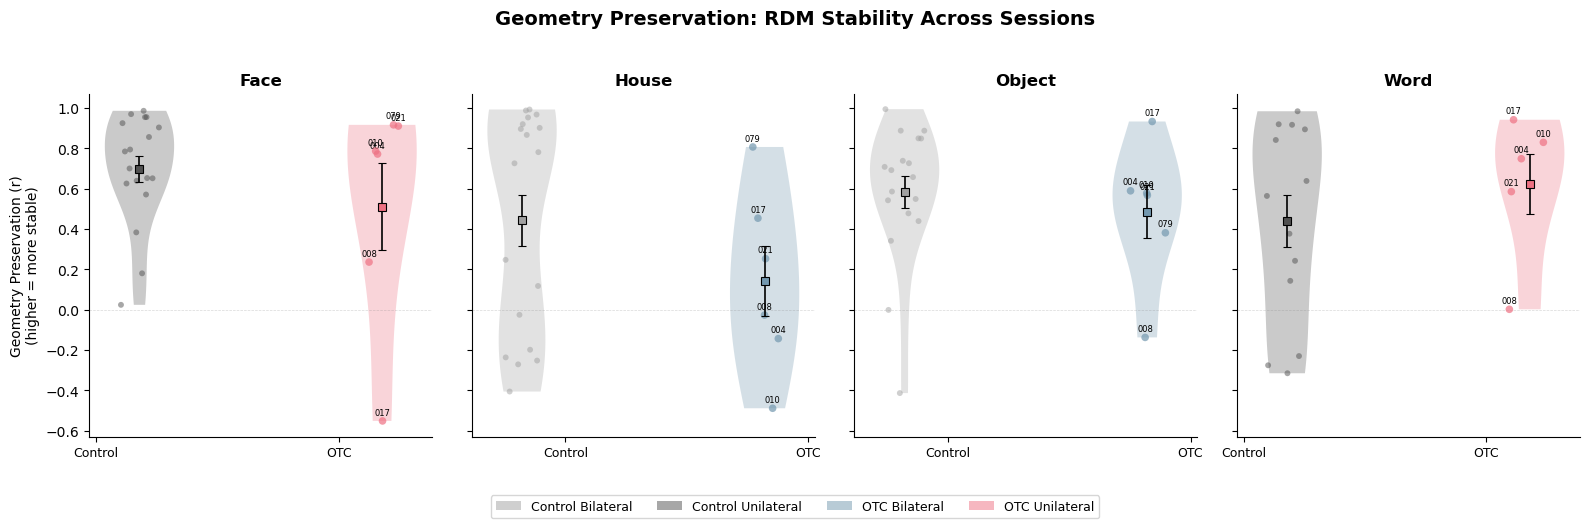

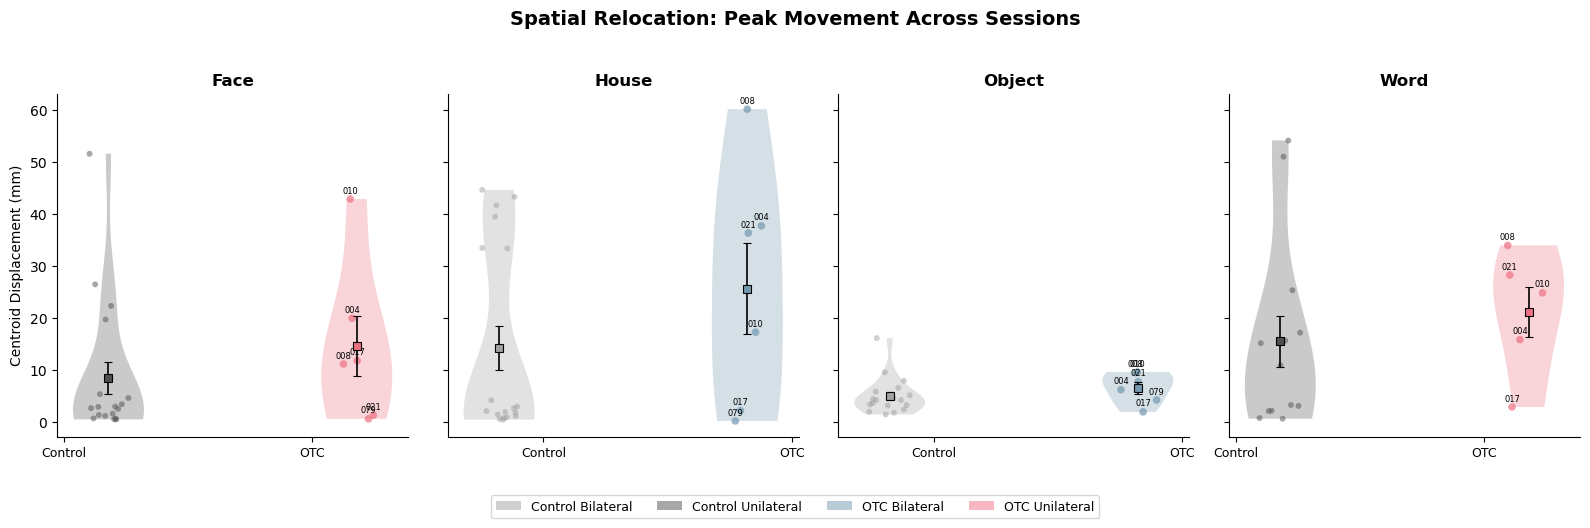

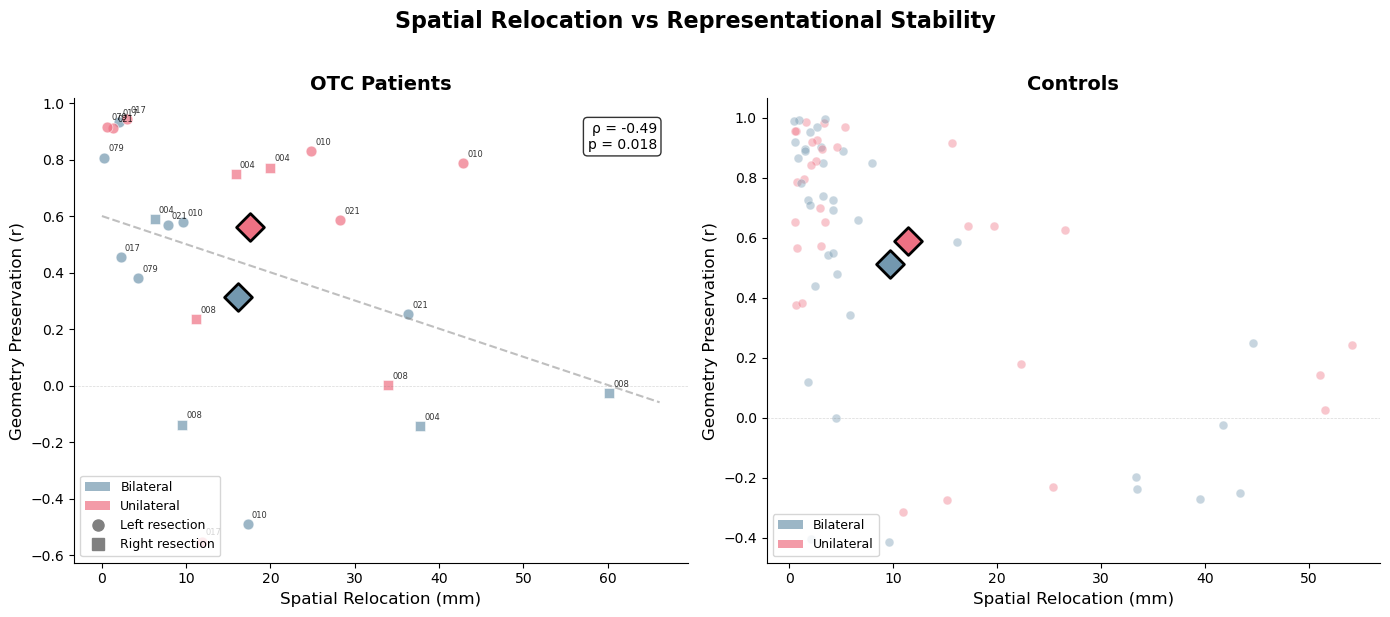

corr_df not available — run pairwise analysis from Liu notebook first


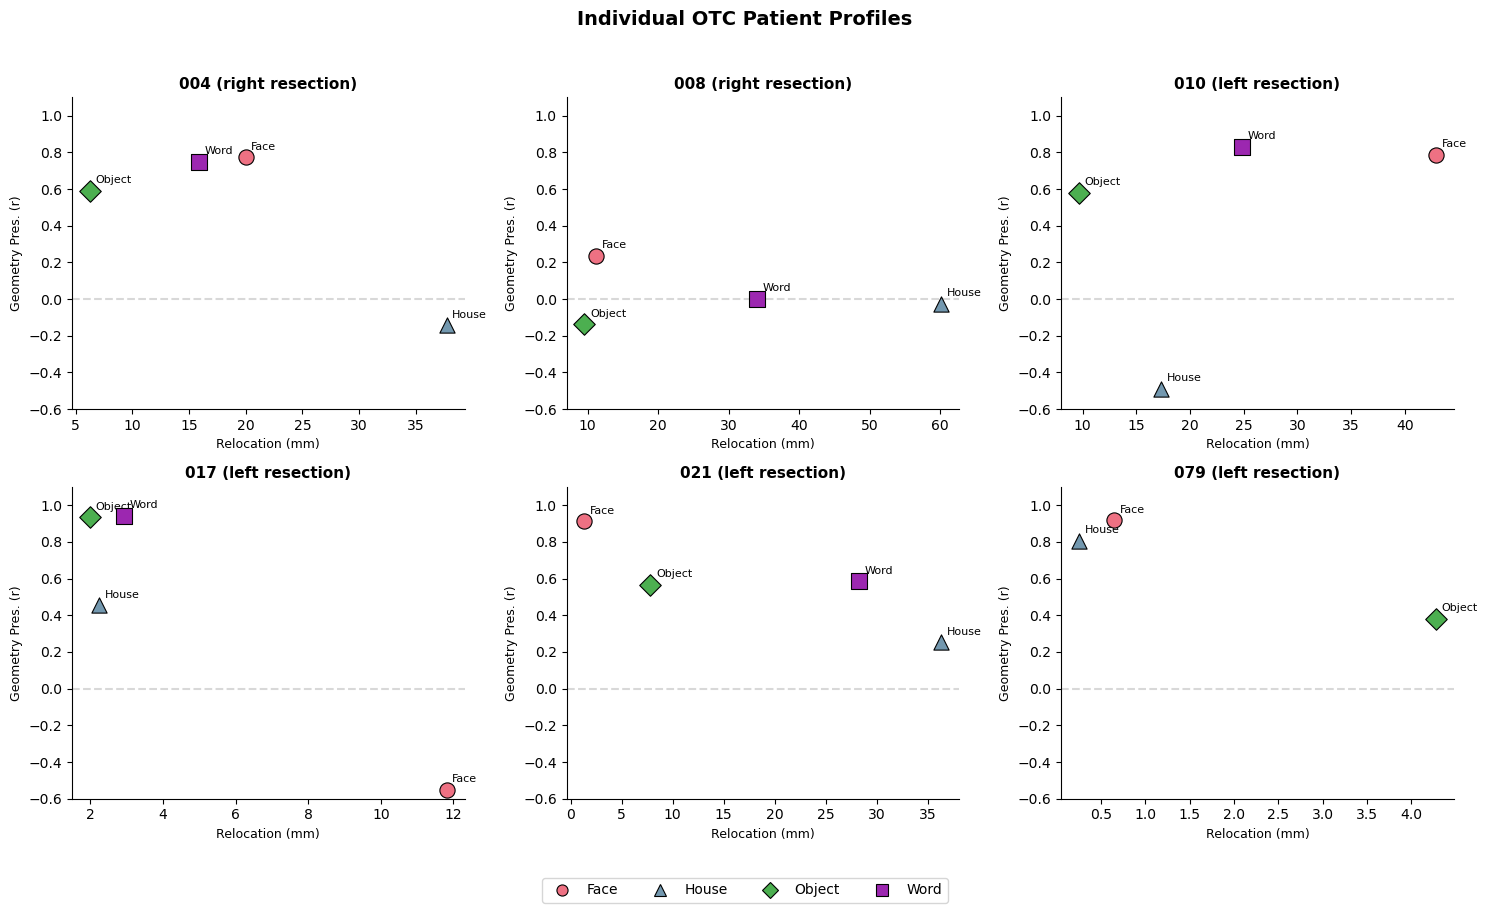

In [27]:
# VISUALIZATION CELLS — Add to geometry_mds notebook
###############################################################################

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np

# Consistent color scheme
COLORS = {
    ('control', 'Left'): '#a0a0a0', ('control', 'Right'): '#505050',
    ('OTC', 'Left'): '#7398af', ('OTC', 'Right'): '#ee7183',
}
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L = '#7398af'
OTC_R = '#ee7183'


# ── FIGURE 1: Geometry Preservation — Violin + Individual Patients ───────────

def fig_geometry_violins(geometry_df):
    """Violin plot: geometry preservation by group × category type, patients labeled."""
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
    rng = np.random.default_rng(2)
    
    # Slots: control bilateral, control unilateral, OTC bilateral, OTC unilateral
    plot_slots = [
        ('control', 'bilateral', 0.0, CTRL_L),
        ('control', 'unilateral', 0.5, CTRL_R),
        ('OTC', 'bilateral', 1.4, OTC_L),
        ('OTC', 'unilateral', 1.9, OTC_R),
    ]
    
    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        cat_data = geometry_df[geometry_df['category'] == cat]
        vd, vp, vc = [], [], []
        
        for grp, ct, pos, color in plot_slots:
            gd = cat_data[(cat_data['group'] == grp) & 
                          (cat_data['cat_type'] == ct)]
            vals = gd['geometry_preservation'].values
            
            if len(vals) < 2:
                continue
            
            vd.append(vals); vp.append(pos); vc.append(color)
            
            if grp == 'control':
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), pos) + jitter, vals,
                          color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            else:
                # Label individual patients
                for _, row in gd.iterrows():
                    jit = rng.uniform(-0.12, 0.12)
                    ax.scatter(pos + jit, row['geometry_preservation'],
                              color=color, s=30, zorder=3, edgecolors='none', alpha=0.7)
                    label = row['subject'].replace('OTC', '')
                    ax.annotate(label, (pos + jit, row['geometry_preservation']),
                               fontsize=6, ha='center', va='bottom',
                               xytext=(0, 3), textcoords='offset points')
            
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)
        
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.4)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i]); body.set_alpha(0.3); body.set_edgecolor('none')
        
        ax.set_xticks([0.25, 1.65])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Geometry Preservation (r)\n(higher = more stable)')
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control Bilateral'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control Unilateral'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Bilateral'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Unilateral'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))
    
    plt.suptitle('Geometry Preservation: RDM Stability Across Sessions',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(HOME_OUTPUT / 'fig1_geometry_violins.png'), dpi=300, bbox_inches='tight')
    plt.show()


fig_geometry_violins(geometry_df)


# ── FIGURE 2: Spatial Relocation — Violin + Individual Patients ──────────────

def fig_spatial_violins(spatial_df):
    """Violin plot: spatial relocation by group × category type, patients labeled."""
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
    rng = np.random.default_rng(2)
    
    plot_slots = [
        ('control', 'bilateral', 0.0, CTRL_L),
        ('control', 'unilateral', 0.5, CTRL_R),
        ('OTC', 'bilateral', 1.4, OTC_L),
        ('OTC', 'unilateral', 1.9, OTC_R),
    ]
    
    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        cat_data = spatial_df[spatial_df['category'] == cat]
        vd, vp, vc = [], [], []
        
        for grp, ct, pos, color in plot_slots:
            gd = cat_data[(cat_data['group'] == grp) & 
                          (cat_data['cat_type'] == ct)]
            vals = gd['relocation_mm'].values
            
            if len(vals) < 2:
                continue
            
            vd.append(vals); vp.append(pos); vc.append(color)
            
            if grp == 'control':
                jitter = rng.uniform(-0.12, 0.12, len(vals))
                ax.scatter(np.full(len(vals), pos) + jitter, vals,
                          color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            else:
                for _, row in gd.iterrows():
                    jit = rng.uniform(-0.12, 0.12)
                    ax.scatter(pos + jit, row['relocation_mm'],
                              color=color, s=30, zorder=3, edgecolors='none', alpha=0.7)
                    label = row['subject'].replace('OTC', '')
                    ax.annotate(label, (pos + jit, row['relocation_mm']),
                               fontsize=6, ha='center', va='bottom',
                               xytext=(0, 3), textcoords='offset points')
            
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals)/np.sqrt(len(vals)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)
        
        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.4)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i]); body.set_alpha(0.3); body.set_edgecolor('none')
        
        ax.set_xticks([0.25, 1.65])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Centroid Displacement (mm)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control Bilateral'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control Unilateral'),
        Patch(facecolor=OTC_L, alpha=0.5, label='OTC Bilateral'),
        Patch(facecolor=OTC_R, alpha=0.5, label='OTC Unilateral'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))
    
    plt.suptitle('Spatial Relocation: Peak Movement Across Sessions',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(HOME_OUTPUT / 'fig2_spatial_violins.png'), dpi=300, bbox_inches='tight')
    plt.show()


fig_spatial_violins(spatial_df)


# ── FIGURE 3: Scatter — Relocation vs Geometry (the key relationship) ────────

def fig_relocation_vs_geometry(spatial_df, geometry_df):
    """Scatter: spatial relocation vs geometry preservation, patients labeled."""
    
    merged = spatial_df.merge(geometry_df,
                              on=['subject_id', 'hemi', 'category', 'group', 'cat_type',
                                  'surgery_side', 'status', 'subject'],
                              suffixes=('_sp', '_gm'))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cat_colors = {'bilateral': OTC_L, 'unilateral': OTC_R}
    surgery_markers = {'left': 'o', 'right': 's'}
    
    # Panel A: OTC
    ax = axes[0]
    otc = merged[merged['group'] == 'OTC']
    
    for _, row in otc.iterrows():
        c = cat_colors[row['cat_type']]
        m = surgery_markers.get(row['surgery_side'], 'o')
        ax.scatter(row['relocation_mm'], row['geometry_preservation'],
                  c=c, marker=m, s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
        label = row['subject'].replace('OTC', '')
        ax.annotate(label, (row['relocation_mm'], row['geometry_preservation']),
                   fontsize=6, ha='left', va='bottom',
                   xytext=(3, 3), textcoords='offset points', alpha=0.8)
    
    # Group means with large diamonds
    for ct in ['bilateral', 'unilateral']:
        sub = otc[otc['cat_type'] == ct]
        if len(sub) > 0:
            ax.scatter(sub['relocation_mm'].mean(), sub['geometry_preservation'].mean(),
                      c=cat_colors[ct], marker='D', s=200, edgecolors='black', linewidth=2,
                      zorder=10, label=f'{ct.title()} mean')
    
    # Trend line
    if len(otc) > 3:
        z = np.polyfit(otc['relocation_mm'], otc['geometry_preservation'], 1)
        x_line = np.linspace(0, otc['relocation_mm'].max() * 1.1, 50)
        ax.plot(x_line, np.polyval(z, x_line), '--', color='gray', alpha=0.5)
    
    from scipy.stats import spearmanr
    if len(otc) > 3:
        rho, pval = spearmanr(otc['relocation_mm'], otc['geometry_preservation'])
        ax.text(0.95, 0.95, f'ρ = {rho:.2f}\np = {pval:.3f}',
               transform=ax.transAxes, ha='right', va='top', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    ax.set_xlabel('Spatial Relocation (mm)', fontsize=12)
    ax.set_ylabel('Geometry Preservation (r)', fontsize=12)
    ax.set_title('OTC Patients', fontsize=14, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    handles = [
        Patch(facecolor=OTC_L, alpha=0.7, label='Bilateral'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Unilateral'),
        Line2D([0], [0], marker='o', color='gray', linestyle='None',
               markersize=8, label='Left resection'),
        Line2D([0], [0], marker='s', color='gray', linestyle='None',
               markersize=8, label='Right resection'),
    ]
    ax.legend(handles=handles, fontsize=9, loc='lower left')
    
    # Panel B: Controls
    ax = axes[1]
    ctrl = merged[merged['status'] == 'control']
    
    for _, row in ctrl.iterrows():
        c = cat_colors[row['cat_type']]
        ax.scatter(row['relocation_mm'], row['geometry_preservation'],
                  c=c, marker='o', s=40, alpha=0.4, edgecolors='white', linewidth=0.5)
    
    for ct in ['bilateral', 'unilateral']:
        sub = ctrl[ctrl['cat_type'] == ct]
        if len(sub) > 0:
            ax.scatter(sub['relocation_mm'].mean(), sub['geometry_preservation'].mean(),
                      c=cat_colors[ct], marker='D', s=200, edgecolors='black', linewidth=2,
                      zorder=10, label=f'{ct.title()} mean')
    
    ax.set_xlabel('Spatial Relocation (mm)', fontsize=12)
    ax.set_ylabel('Geometry Preservation (r)', fontsize=12)
    ax.set_title('Controls', fontsize=14, fontweight='bold')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(handles=handles[:2], fontsize=9, loc='lower left')
    
    plt.suptitle('Spatial Relocation vs Representational Stability',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(HOME_OUTPUT / 'fig3_scatter.png'), dpi=300, bbox_inches='tight')
    plt.show()


fig_relocation_vs_geometry(spatial_df, geometry_df)


# ── FIGURE 4: Pairwise Heatmaps (needs corr_df from Liu notebook) ───────────

def fig_pairwise_heatmaps(corr_df):
    """3-panel heatmap: Control vs OTC-left vs OTC-right, unilateral ROIs."""
    
    uni = corr_df[corr_df['roi_type'] == 'unilateral']
    cats = ['face', 'word', 'house', 'object']
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    
    for ax_idx, (grp, title) in enumerate([
        ('control', 'Controls'),
        ('OTC-left', 'Left Resection\n(Word → Right Hemi)'),
        ('OTC-right', 'Right Resection\n(Face → Left Hemi)')
    ]):
        ax = axes[ax_idx]
        gd = uni[uni['group'] == grp]
        
        mat = np.full((4, 4), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    continue
                pair = f'{ci}-{cj}'
                vals = gd[gd['pair'] == pair]['fisher_r']
                if len(vals) == 0:
                    vals = gd[gd['pair'] == f'{cj}-{ci}']['fisher_r']
                if len(vals) > 0:
                    mat[i, j] = vals.mean()
        
        im = ax.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        
        ax.set_xticks(range(4))
        ax.set_xticklabels([c.title() for c in cats], fontsize=10)
        ax.set_yticks(range(4))
        ax.set_yticklabels([c.title() for c in cats], fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold')
        
        for i in range(4):
            for j in range(4):
                if not np.isnan(mat[i, j]):
                    color = 'white' if mat[i, j] > 1.0 else 'black'
                    ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                           fontsize=9, color=color, fontweight='bold')
    
    plt.colorbar(im, ax=axes, shrink=0.8,
                label='Fisher-z correlation\n(higher = less distinct)')
    plt.suptitle('Category Pairwise Correlations in Unilateral ROIs',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(HOME_OUTPUT / 'fig4_heatmaps.png'), dpi=300, bbox_inches='tight')
    plt.show()


try:
    fig_pairwise_heatmaps(corr_df)
except NameError:
    print("corr_df not available — run pairwise analysis from Liu notebook first")


# ── FIGURE 5: Individual Patient Profiles ────────────────────────────────────

def fig_patient_profiles(spatial_df, geometry_df):
    """Per-patient scatter: relocation vs geometry for each category."""
    
    otc_sp = spatial_df[spatial_df['group'] == 'OTC']
    otc_gm = geometry_df[geometry_df['group'] == 'OTC']
    merged = otc_sp.merge(otc_gm,
                          on=['subject_id', 'hemi', 'category', 'subject',
                              'surgery_side', 'cat_type'],
                          suffixes=('_sp', '_gm'))
    
    patients = sorted(merged['subject'].unique())
    n = len(patients)
    if n == 0:
        print("No OTC patients with longitudinal data")
        return
    
    cols = min(n, 3)
    rows_n = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_n, cols, figsize=(5*cols, 4.5*rows_n), squeeze=False)
    
    cat_colors = {'face': OTC_R, 'word': '#9C27B0', 'house': OTC_L, 'object': '#4CAF50'}
    cat_markers = {'face': 'o', 'word': 's', 'house': '^', 'object': 'D'}
    
    for idx, patient in enumerate(patients):
        ax = axes[idx // cols][idx % cols]
        pd_data = merged[merged['subject'] == patient]
        side = pd_data['surgery_side'].iloc[0]
        
        for _, row in pd_data.iterrows():
            ax.scatter(row['relocation_mm'], row['geometry_preservation'],
                      c=cat_colors[row['category']], marker=cat_markers[row['category']],
                      s=120, edgecolors='black', linewidth=0.8, zorder=5)
            ax.annotate(row['category'].title(),
                       (row['relocation_mm'], row['geometry_preservation']),
                       fontsize=8, ha='left', va='bottom',
                       xytext=(4, 4), textcoords='offset points')
        
        short_name = patient.replace('OTC', '')
        ax.set_title(f"{short_name} ({side} resection)", fontsize=11, fontweight='bold')
        ax.set_xlabel('Relocation (mm)', fontsize=9)
        ax.set_ylabel('Geometry Pres. (r)', fontsize=9)
        ax.set_ylim(-0.6, 1.1)
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    for idx in range(n, rows_n * cols):
        axes[idx // cols][idx % cols].set_visible(False)
    
    handles = [Line2D([0], [0], marker=cat_markers[c], color=cat_colors[c],
               linestyle='None', markersize=8, markeredgecolor='black',
               markeredgewidth=0.8, label=c.title()) for c in CATEGORIES]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10,
              frameon=True, bbox_to_anchor=(0.5, -0.02))
    
    plt.suptitle('Individual OTC Patient Profiles', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(str(HOME_OUTPUT / 'fig5_patient_profiles.png'), dpi=300, bbox_inches='tight')
    plt.show()


fig_patient_profiles(spatial_df, geometry_df)

In [29]:
###############################################################################
# CELL A: Bootstrap CIs per category (not collapsed)
###############################################################################

def bootstrap_ci(data, n_boot=10000, ci=95):
    """Return mean and bootstrapped CI."""
    rng = np.random.default_rng(42)
    means = [np.mean(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(means, (100 - ci) / 2)
    hi = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lo, hi


def report_geometry_per_category(geometry_df):
    """Per-category geometry preservation with bootstrapped 95% CIs."""
    
    print("GEOMETRY PRESERVATION PER CATEGORY (bootstrapped 95% CI)")
    print("=" * 80)
    print("* = reorganized category (in non-typical hemisphere)")
    print()
    
    # Define which category is reorganized for each surgery side
    reorg = {
        'left': 'word',   # left resection → word reorganizes to R
        'right': 'face',  # right resection → face reorganizes to L
    }
    
    # ── Individual patients ──
    print("INDIVIDUAL OTC PATIENTS:")
    print(f"{'Patient':<12} {'Surgery':<10} {'Face':<12} {'House':<12} {'Object':<12} {'Word':<12}")
    print("-" * 70)
    
    otc = geometry_df[geometry_df['group'] == 'OTC']
    for sub in sorted(otc['subject'].unique()):
        sd = otc[otc['subject'] == sub]
        side = sd['surgery_side'].iloc[0]
        short = sub.replace('OTC', '')
        
        row = f"{short:<12} {side:<10}"
        for cat in ['face', 'house', 'object', 'word']:
            val = sd[sd['category'] == cat]['geometry_preservation']
            if len(val) > 0:
                v = val.values[0]
                star = "*" if reorg.get(side) == cat else " "
                row += f" {v:>6.3f}{star}    "
            else:
                row += f"   {'—':<9}"
        print(row)
    
    # ── Group means with bootstrap CIs ──
    print(f"\nGROUP MEANS (bootstrapped 95% CI):")
    print(f"{'Group':<12} {'n':<5} {'Face':<20} {'House':<20} {'Object':<20} {'Word':<20}")
    print("-" * 80)
    
    for grp in ['OTC', 'nonOTC', 'control']:
        gd = geometry_df[geometry_df['group'] == grp]
        n = gd['subject'].nunique()
        row = f"{grp:<12} {n:<5}"
        
        for cat in ['face', 'house', 'object', 'word']:
            vals = gd[gd['category'] == cat]['geometry_preservation'].values
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                row += f" {m:.3f} [{lo:.3f},{hi:.3f}]"
            elif len(vals) == 1:
                row += f" {vals[0]:.3f} [n=1]       "
            else:
                row += f" {'—':<19}"
        print(row)
    
    # ── OTC by surgery side ──
    print(f"\nOTC BY SURGERY SIDE:")
    print(f"{'Group':<16} {'n':<5} {'Face':<20} {'House':<20} {'Object':<20} {'Word':<20}")
    print("-" * 85)
    
    for side in ['left', 'right']:
        sd = otc[otc['surgery_side'] == side]
        n = sd['subject'].nunique()
        star_cat = reorg[side]
        row = f"OTC-{side:<12} {n:<5}"
        
        for cat in ['face', 'house', 'object', 'word']:
            vals = sd[sd['category'] == cat]['geometry_preservation'].values
            star = "*" if cat == star_cat else " "
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                row += f"{m:.3f}{star}[{lo:.3f},{hi:.3f}]"
            elif len(vals) == 1:
                row += f" {vals[0]:.3f}{star}[n=1]       "
            else:
                row += f" {'—':<19}"
        print(row)
    
    # ── Statistical tests per category ──
    print(f"\nOTC vs CONTROLS PER CATEGORY (Mann-Whitney, bootstrapped CIs):")
    print(f"{'Category':<10} {'OTC mean':<12} {'Ctrl mean':<12} {'U':<10} {'p':<10} {'Direction'}")
    print("-" * 65)
    
    from scipy.stats import mannwhitneyu
    
    for cat in ['face', 'house', 'object', 'word']:
        otc_vals = otc[otc['category'] == cat]['geometry_preservation'].values
        ctrl_vals = geometry_df[(geometry_df['group'] == 'control') & 
                                (geometry_df['category'] == cat)]['geometry_preservation'].values
        
        if len(otc_vals) >= 2 and len(ctrl_vals) >= 2:
            u, p = mannwhitneyu(otc_vals, ctrl_vals, alternative='less')
            direction = "OTC < Ctrl" if np.mean(otc_vals) < np.mean(ctrl_vals) else "OTC ≥ Ctrl"
            print(f"{cat:<10} {np.mean(otc_vals):<12.3f} {np.mean(ctrl_vals):<12.3f} "
                  f"{u:<10.0f} {p:<10.4f} {direction}")
    
    # ── Reorganized vs typical ──
    print(f"\nREORGANIZED vs TYPICAL (unilateral categories only):")
    
    reorg_vals = []
    typical_vals = []
    
    for _, row in otc.iterrows():
        if row['cat_type'] != 'unilateral':
            continue
        side = row['surgery_side']
        if reorg.get(side) == row['category']:
            reorg_vals.append(row['geometry_preservation'])
        else:
            typical_vals.append(row['geometry_preservation'])
    
    reorg_vals = np.array(reorg_vals)
    typical_vals = np.array(typical_vals)
    
    if len(reorg_vals) >= 2:
        m, lo, hi = bootstrap_ci(reorg_vals)
        print(f"  Reorganized: {m:.3f} [{lo:.3f}, {hi:.3f}] (n={len(reorg_vals)})")
    if len(typical_vals) >= 2:
        m, lo, hi = bootstrap_ci(typical_vals)
        print(f"  Typical:     {m:.3f} [{lo:.3f}, {hi:.3f}] (n={len(typical_vals)})")
    
    if len(reorg_vals) >= 2 and len(typical_vals) >= 2:
        u, p = mannwhitneyu(reorg_vals, typical_vals, alternative='greater')
        print(f"  Reorganized > Typical: U={u:.0f}, p={p:.4f}")


report_geometry_per_category(geometry_df)

GEOMETRY PRESERVATION PER CATEGORY (bootstrapped 95% CI)
* = reorganized category (in non-typical hemisphere)

INDIVIDUAL OTC PATIENTS:
Patient      Surgery    Face         House        Object       Word        
----------------------------------------------------------------------
004          right       0.772*     -0.143       0.590       0.749     
008          right       0.236*     -0.027      -0.137       0.002     
010          left        0.787      -0.489       0.578       0.830*    
017          left       -0.552       0.454       0.933       0.942*    
021          left        0.911       0.253       0.567       0.586*    
079          left        0.917       0.807       0.381        —        

GROUP MEANS (bootstrapped 95% CI):
Group        n     Face                 House                Object               Word                
--------------------------------------------------------------------------------
OTC          6     0.512 [0.047,0.867] 0.143 [-0.184,0.479] 0.485

In [33]:
###############################################################################
# CELL C: Multi-Contrast Geometry Runner
###############################################################################

def run_geometry_all_contrasts():
    """Run geometry analysis with all three contrast maps."""
    
    contrast_maps = {
        'differential': {'face': 1, 'house': 2, 'object': 3, 'word': 4},
        'cat_vs_scramble': {'face': 10, 'house': 11, 'object': 3, 'word': 12},
        'hybrid': {'face': 1, 'house': 2, 'object': 3, 'word': 12},
    }
    
    all_results = {}
    
    for name, cope_map in contrast_maps.items():
        print(f"\n{'='*70}")
        print(f"CONTRAST MAP: {name} → {cope_map}")
        print(f"{'='*70}")
        
        # Temporarily override LOC_COPES
        global LOC_COPES
        original = LOC_COPES.copy()
        LOC_COPES = cope_map
        
        clear_cache()
        spatial, geometry, mds = compute_all_metrics(radius=6)
        
        all_results[name] = {
            'spatial': spatial,
            'geometry': geometry,
            'mds': mds,
        }
        
        # Quick summary
        otc_g = geometry[geometry['group'] == 'OTC']
        print(f"\n  OTC Geometry per category:")
        for cat in ['face', 'house', 'object', 'word']:
            vals = otc_g[otc_g['category'] == cat]['geometry_preservation']
            if len(vals) > 0:
                print(f"    {cat}: {vals.mean():.3f} (n={len(vals)})")
        
        # Restore
        LOC_COPES = original
    
    # ── Comparison table ──
    print(f"\n{'='*70}")
    print("CONTRAST MAP COMPARISON: OTC Geometry Preservation")
    print(f"{'='*70}")
    print(f"{'Contrast':<20} {'Face':<10} {'House':<10} {'Object':<10} {'Word':<10}")
    print("-" * 60)
    
    for name, res in all_results.items():
        g = res['geometry']
        otc_g = g[g['group'] == 'OTC']
        row = f"{name:<20}"
        for cat in ['face', 'house', 'object', 'word']:
            vals = otc_g[otc_g['category'] == cat]['geometry_preservation']
            row += f" {vals.mean():.3f}    " if len(vals) > 0 else f" {'—':<9}"
        print(row)
    
    print(f"\n{'Contrast':<20} {'Bilateral':<12} {'Unilateral':<12} {'Diff':<10} {'rho(reloc,geom)':<18} {'p'}")
    print("-" * 75)
    
    from scipy.stats import spearmanr
    
    for name, res in all_results.items():
        g = res['geometry']
        s = res['spatial']
        otc_g = g[g['group'] == 'OTC']
        bil = otc_g[otc_g['cat_type'] == 'bilateral']['geometry_preservation'].mean()
        uni = otc_g[otc_g['cat_type'] == 'unilateral']['geometry_preservation'].mean()
        
        merged = s.merge(g, on=['subject_id', 'hemi', 'category', 'group', 'cat_type',
                                'surgery_side', 'status', 'subject'],
                         suffixes=('_sp', '_gm'))
        otc_m = merged[merged['group'] == 'OTC']
        
        if len(otc_m) > 3:
            rho, p = spearmanr(otc_m['relocation_mm'], otc_m['geometry_preservation'])
            print(f"{name:<20} {bil:<12.3f} {uni:<12.3f} {bil-uni:<+10.3f} "
                  f"{rho:<18.3f} {p:.4f}")
        else:
            print(f"{name:<20} {bil:<12.3f} {uni:<12.3f} {bil-uni:<+10.3f} "
                  f"{'insufficient data'}")
    
    # Save all
    for name, res in all_results.items():
        for metric in ['spatial', 'geometry', 'mds']:
            res[metric].to_csv(HOME_OUTPUT / f'{metric}_{name}.csv', index=False)
    
    print(f"\nSaved all results to {HOME_OUTPUT}")
    return all_results


# Uncomment to run (takes ~10 min for all three):
all_contrast_results = run_geometry_all_contrasts()


CONTRAST MAP: differential → {'face': 1, 'house': 2, 'object': 3, 'word': 4}
Cleared 0 cached files
COMPUTING GEOMETRY + MDS METRICS
Localization: COPEs {'face': 1, 'house': 2, 'object': 3, 'word': 4}
Measurement:  COPEs {'face': 15, 'house': 16, 'object': 17, 'word': 18}
Sphere radius: 6mm
  [50/50] control097 (226s)
  Done: 226s
  Spatial: 101 ROIs
  Geometry: 101 ROIs
  MDS: 404 measurements

  OTC Geometry per category:
    face: 0.512 (n=6)
    house: 0.143 (n=6)
    object: 0.485 (n=6)
    word: 0.622 (n=5)

CONTRAST MAP: cat_vs_scramble → {'face': 10, 'house': 11, 'object': 3, 'word': 12}
Cleared 414 cached files
COMPUTING GEOMETRY + MDS METRICS
Localization: COPEs {'face': 10, 'house': 11, 'object': 3, 'word': 12}
Measurement:  COPEs {'face': 15, 'house': 16, 'object': 17, 'word': 18}
Sphere radius: 6mm
  [50/50] control097 (238s)
  Done: 238s
  Spatial: 108 ROIs
  Geometry: 108 ROIs
  MDS: 432 measurements

  OTC Geometry per category:
    face: 0.502 (n=6)
    house: 0.511 (